# Signal/Noise separation: RNA-FM vs ERNIE-RNA vs RiNALMo

The CURIA pipeline classifies RNA-FM embeddings as **signal** (ncRNA) vs **noise** (intergenic)
using `PCA(16) → LogReg`. Current AUC on RNA-FM: **0.9834**.

Question: do ERNIE-RNA or RiNALMo separate signal from noise better?
If so, the island-alignment pipeline could be simplified.

In [1]:
import sys, random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from sklearn.model_selection import StratifiedShuffleSplit

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "modules" / "RNA-FM"))
sys.path.insert(0, str(REPO_ROOT / "modules" / "RiNALMo"))
sys.path.insert(0, str(REPO_ROOT / "modules" / "pipeline"))

import short_ncrna as sn
from pyrion import TwoBitAccessor
from pyrion.io.bed import read_bed12_file

SEED = 42
random.seed(SEED); np.random.seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
    else "cpu"
)
print("Device:", device)

Device: mps


## Load all three models

In [2]:
# --- RNA-FM (640-dim) ---
import fm
fm_model, fm_alpha = fm.pretrained.rna_fm_t12()
fm_model.eval().to(device)
fm_bc = fm_alpha.get_batch_converter()

def emb_rnafm(seq: str) -> np.ndarray:
    rna = seq.upper().replace("T", "U")
    _, _, tk = fm_bc([("x", rna)])
    tk = tk.to(device)
    with torch.no_grad():
        out = fm_model(tk, repr_layers=[12])["representations"][12]
    return out[0, 1:1 + len(rna), :].cpu().float().numpy()

print("RNA-FM ready (640-dim)")

RNA-FM ready (640-dim)


In [3]:
# --- ERNIE-RNA (768-dim) ---
import multimolecule
from transformers import AutoTokenizer, AutoModel

ern_tokenizer = AutoTokenizer.from_pretrained("multimolecule/ernierna", trust_remote_code=True)
ern_model = AutoModel.from_pretrained("multimolecule/ernierna", trust_remote_code=True)
ern_model = ern_model.to(device).eval()

def emb_ernierna(seq: str) -> np.ndarray:
    rna = seq.upper().replace("T", "U")
    inputs = ern_tokenizer(rna, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        out = ern_model(**inputs, output_hidden_states=True)
    return out.last_hidden_state[0, 1:1 + len(rna), :].cpu().float().numpy()

print("ERNIE-RNA ready (768-dim)")

/Users/Bogdan.Kirilenko/Developer/CURIA_pipeline/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0615 11:48:01.143000 5792 .venv/lib/python3.14/site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
Loading weights: 100%|██████████| 202/202 [00:00<00:00, 7975.01it/s]
[transformers] ErnieRnaModel LOAD REPORT from: multimolecule/ernierna
Key                                 | Status     |  | 
------------------------------------+------------+--+-
lm_head.transform.layer_norm.weight | UNEXPECTED |  | 
lm_head.transform.dense.bias        | UNEXPECTED |  | 
lm_head.bias                        | UNEXPECTED |  | 
lm_head.transform.layer_norm.bias   | UNEXPECTED |  | 
lm_head.transform.dense.weight      | UNEXPECTED |  | 



ERNIE-RNA ready (768-dim)


In [4]:
# --- RiNALMo (1280-dim) ---
from rinalmo.pretrained import get_pretrained_model

rin_model, rin_alpha = get_pretrained_model(model_name="giga-v1")
rin_model = rin_model.to(device).eval()

def emb_rinalmo(seq: str) -> np.ndarray:
    rna = seq.upper().replace("T", "U")
    tokens = torch.tensor(
        rin_alpha.batch_tokenize([rna]), dtype=torch.int64, device=device
    )
    with torch.no_grad():
        out = rin_model(tokens)
    return out["representation"][0, 1:1 + len(rna), :].cpu().float().numpy()

print("RiNALMo ready (1280-dim)")

RiNALMo ready (1280-dim)


In [5]:
MODELS = {
    "RNA-FM":     {"emb_fn": emb_rnafm,   "dim": 640},
    "ERNIE-RNA":  {"emb_fn": emb_ernierna, "dim": 768},
    "RiNALMo":    {"emb_fn": emb_rinalmo,  "dim": 1280},
}
print(f"All {len(MODELS)} models loaded")

All 3 models loaded


## Extract signal + noise windows

Matching the pipeline's island-detection parameters:
- Window size: 72 nt (same as `reference_islands_scanner.py`)
- **Signal**: ncRNA windows from reference annotation
- **Noise**: random intergenic windows from hg38

In [6]:
WINDOW_SIZE = 72
N_SIGNAL = 500
N_NOISE = 500

BED_PATH    = REPO_ROOT / "input_data" / "reference_annotation" / "hg38.input.w.tRNA.bed"
TWOBIT_PATH = REPO_ROOT / "input_data" / "2bit" / "hg38.2bit"
META_PATH   = REPO_ROOT / "input_data" / "reference_annotation" / "test_sample.metadata.tsv"

accessor = TwoBitAccessor(str(TWOBIT_PATH))
bed_data = read_bed12_file(str(BED_PATH))
meta_df  = pd.read_csv(META_PATH, sep="\t")
biotype_map = dict(zip(meta_df["transcript_id"], meta_df["transcript_biotype"]))

# --- Signal windows: extract 72-nt windows from ncRNAs ---
SIGNAL_BIOTYPES = {"tRNA", "snoRNA", "miRNA", "snRNA", "misc_RNA", "scaRNA"}
rng = random.Random(SEED)

signal_windows = []  # (seq, biotype)
for t in bed_data:
    bt = None
    if t.id.startswith("tRNA-") and "Und-NNN" not in t.id:
        bt = "tRNA"
    else:
        bt = biotype_map.get(t.id.split(".")[0])
    if bt not in SIGNAL_BIOTYPES:
        continue
    seq = sn._get_spliced_sequence(t, accessor)
    if not seq or "N" in seq.upper() or len(seq) < WINDOW_SIZE:
        continue
    seq = seq.upper().replace("T", "U")
    # Take 1 random window per transcript
    start = rng.randint(0, len(seq) - WINDOW_SIZE)
    signal_windows.append((seq[start:start + WINDOW_SIZE], bt))

rng.shuffle(signal_windows)
signal_windows = signal_windows[:N_SIGNAL]

# Count per biotype
bt_counts = {}
for _, bt in signal_windows:
    bt_counts[bt] = bt_counts.get(bt, 0) + 1
print(f"Signal windows: {len(signal_windows)}")
for bt, n in sorted(bt_counts.items(), key=lambda x: -x[1]):
    print(f"  {bt}: {n}")

Signal windows: 500
  tRNA: 399
  miRNA: 74
  snoRNA: 27


In [7]:
# --- Noise windows: random intergenic from hg38 ---
chrom_sizes = {}
chrom_sizes_path = REPO_ROOT / "input_data" / "reference_annotation" / "hg38.chrom.sizes"
if not chrom_sizes_path.exists():
    chrom_sizes_path = REPO_ROOT / "input_data" / "reference_annotations" / "hg38.chrom.sizes"

if chrom_sizes_path.exists():
    with open(chrom_sizes_path) as f:
        for line in f:
            if line.strip():
                parts = line.strip().split()
                chrom_sizes[parts[0]] = int(parts[1])
else:
    # Fallback: approximate sizes for main chromosomes
    for i in list(range(1, 23)) + ["X", "Y"]:
        chrom_sizes[f"chr{i}"] = 200_000_000

chroms = [c for c in chrom_sizes if c.startswith("chr") and "_" not in c and c != "chrM"]
print(f"Using {len(chroms)} chromosomes")

noise_windows = []
rng_noise = random.Random(SEED + 1)
while len(noise_windows) < N_NOISE:
    chrom = rng_noise.choice(chroms)
    max_start = chrom_sizes[chrom] - WINDOW_SIZE
    if max_start <= 0:
        continue
    start = rng_noise.randint(0, max_start)
    try:
        seq = str(accessor.fetch(chrom, start, start + WINDOW_SIZE)).upper().replace("T", "U")
        if "N" not in seq and len(seq) == WINDOW_SIZE:
            noise_windows.append(seq)
    except:
        continue

print(f"Noise windows: {len(noise_windows)}")

# Combine
all_seqs = [s for s, _ in signal_windows] + noise_windows
all_labels = [1] * len(signal_windows) + [0] * len(noise_windows)
all_biotypes = [bt for _, bt in signal_windows] + ["noise"] * len(noise_windows)

print(f"\nTotal: {len(all_seqs)} windows ({sum(all_labels)} signal, {len(all_labels) - sum(all_labels)} noise)")
print(f"All windows are {WINDOW_SIZE} nt")

Using 24 chromosomes
Noise windows: 500

Total: 1000 windows (500 signal, 500 noise)
All windows are 72 nt


## Embed all windows with all 3 models

Mean-pool per-token embeddings to get one vector per window (matching pipeline behavior).

In [8]:
# Embed all windows: per-token -> mean-pool -> (D,) per window
window_embs = {}  # model_name -> (N, D) array

for mname, minfo in MODELS.items():
    fn = minfo["emb_fn"]
    print(f"\n=== {mname} (dim={minfo['dim']}) ===")
    vecs = []
    for i, seq in enumerate(all_seqs):
        tok_emb = fn(seq)          # (L, D)
        vecs.append(tok_emb.mean(axis=0))  # (D,)
        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{len(all_seqs)}")
    window_embs[mname] = np.vstack(vecs).astype(np.float32)
    print(f"  done: {window_embs[mname].shape}")

print("\nAll embeddings extracted")


=== RNA-FM (dim=640) ===
  100/1000
  200/1000
  300/1000
  400/1000
  500/1000
  600/1000
  700/1000
  800/1000
  900/1000
  1000/1000
  done: (1000, 640)

=== ERNIE-RNA (dim=768) ===
  100/1000
  200/1000
  300/1000
  400/1000
  500/1000
  600/1000
  700/1000
  800/1000
  900/1000
  1000/1000
  done: (1000, 768)

=== RiNALMo (dim=1280) ===
  100/1000
  200/1000
  300/1000
  400/1000
  500/1000
  600/1000
  700/1000
  800/1000
  900/1000
  1000/1000
  done: (1000, 1280)

All embeddings extracted


## Fit PCA (k=16) + train LogReg per model

In [9]:
K_PCA = 16
y = np.array(all_labels)

# Stratified 80/20 split
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(sss.split(y, y))

results = {}  # model_name -> {pca, logreg, y_prob_test, auc, ...}

for mname in MODELS:
    X_raw = window_embs[mname]

    # Fit PCA on training set only
    pca = PCA(n_components=K_PCA).fit(X_raw[train_idx])
    X_pca = pca.transform(X_raw)
    var_explained = pca.explained_variance_ratio_.sum()

    # Train LogReg
    lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
    lr.fit(X_pca[train_idx], y[train_idx])

    # Evaluate
    y_prob = lr.predict_proba(X_pca)[:, 1]
    y_pred = lr.predict(X_pca[test_idx])
    auc = roc_auc_score(y[test_idx], y_prob[test_idx])
    train_auc = roc_auc_score(y[train_idx], y_prob[train_idx])

    results[mname] = {
        "pca": pca, "logreg": lr, "X_pca": X_pca,
        "y_prob": y_prob, "auc": auc, "train_auc": train_auc,
        "var_explained": var_explained,
    }
    print(f"{mname}: var@k={K_PCA} = {var_explained:.1%}, train AUC = {train_auc:.4f}, test AUC = {auc:.4f}")

print("\nAll classifiers trained")

RNA-FM: var@k=16 = 84.9%, train AUC = 0.9847, test AUC = 0.9837
ERNIE-RNA: var@k=16 = 79.6%, train AUC = 0.9870, test AUC = 0.9828
RiNALMo: var@k=16 = 84.5%, train AUC = 0.9725, test AUC = 0.9733

All classifiers trained


## ROC curves (all models overlaid)

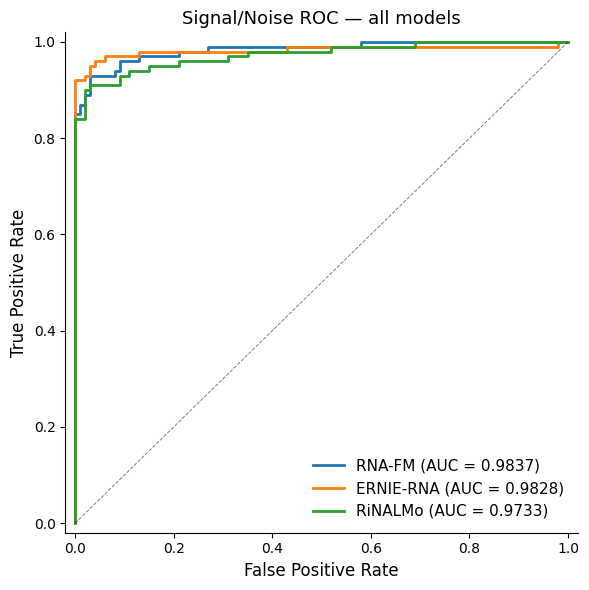

In [10]:
model_colors = {"RNA-FM": "#1f77b4", "ERNIE-RNA": "#ff7f0e", "RiNALMo": "#2ca02c"}

fig, ax = plt.subplots(figsize=(6, 6))
for mname in MODELS:
    r = results[mname]
    fpr, tpr, _ = roc_curve(y[test_idx], r["y_prob"][test_idx])
    ax.plot(fpr, tpr, color=model_colors[mname], lw=2,
            label=f"{mname} (AUC = {r['auc']:.4f})")

ax.plot([0, 1], [0, 1], "k--", lw=0.7, alpha=0.5)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("Signal/Noise ROC — all models", fontsize=13)
ax.legend(fontsize=11, loc="lower right", frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.show()

## PCA space visualization (PC1 vs PC2)

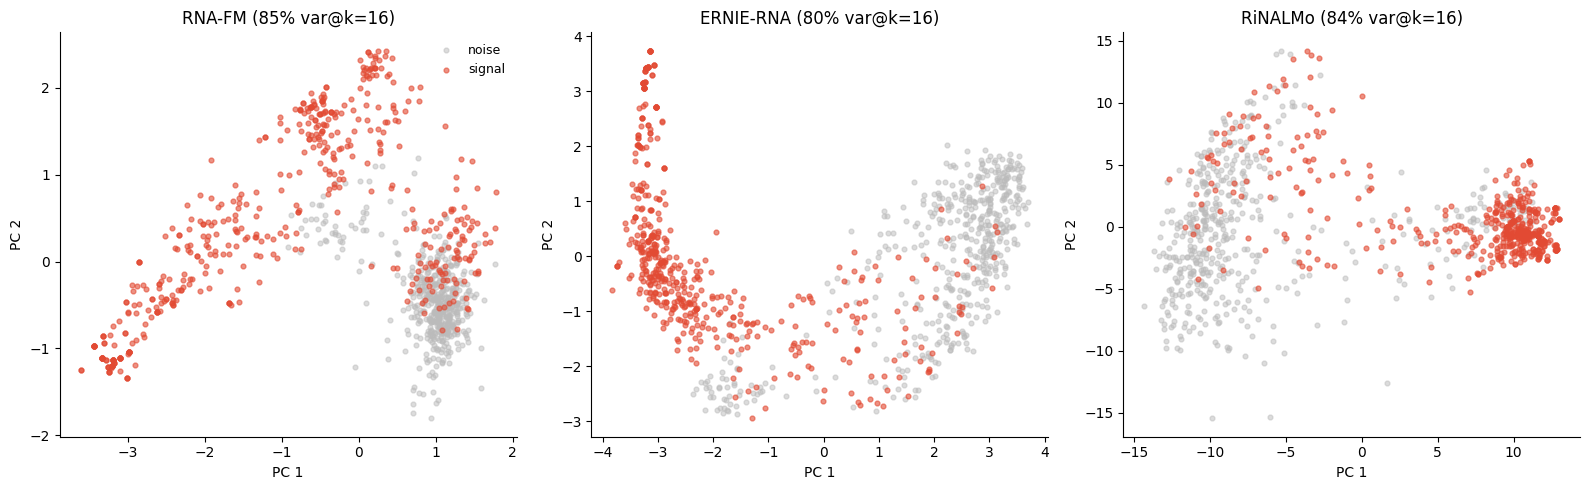

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, mname in enumerate(MODELS):
    ax = axes[idx]
    X = results[mname]["X_pca"]
    mask_s = np.array(all_labels) == 1
    mask_n = ~mask_s
    ax.scatter(X[mask_n, 0], X[mask_n, 1], c="#bbb", s=12, alpha=0.5, label="noise", zorder=2)
    ax.scatter(X[mask_s, 0], X[mask_s, 1], c="#e24a33", s=12, alpha=0.6, label="signal", zorder=3)
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_title(f"{mname} ({results[mname]['var_explained']:.0%} var@k=16)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if idx == 0:
        ax.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

## Per-biotype recall at 5% FPR

In [12]:
# Find the probability threshold that gives ~5% FPR on noise in test set
biotypes_arr = np.array(all_biotypes)

bt_rows = []
for mname in MODELS:
    r = results[mname]
    probs = r["y_prob"]
    # Get threshold at 5% FPR from test noise
    noise_probs_test = probs[test_idx][y[test_idx] == 0]
    thresh_5pct = np.percentile(noise_probs_test, 95)  # top 5% of noise = FPR=5%

    for bt in sorted(set(all_biotypes) - {"noise"}):
        bt_mask = biotypes_arr == bt
        bt_test = bt_mask[test_idx]
        if bt_test.sum() == 0:
            continue
        recall = (probs[test_idx][bt_test] >= thresh_5pct).mean()
        bt_rows.append({"model": mname, "biotype": bt, "recall@5%FPR": recall,
                        "n_test": int(bt_test.sum())})

bt_df = pd.DataFrame(bt_rows)
pivot = bt_df.pivot(index="biotype", columns="model", values="recall@5%FPR")
pivot = pivot[list(MODELS.keys())]  # keep model order
print("Recall per biotype at 5% FPR:\n")
print(pivot.to_string(float_format="{:.2f}".format))

Recall per biotype at 5% FPR:

model    RNA-FM  ERNIE-RNA  RiNALMo
biotype                            
miRNA      0.78       1.00     0.67
snoRNA     0.25       0.00     0.25
tRNA       1.00       1.00     1.00


## Decision boundary sharpness

Histograms of predicted probabilities for signal vs noise. Sharper bimodal = more confident.

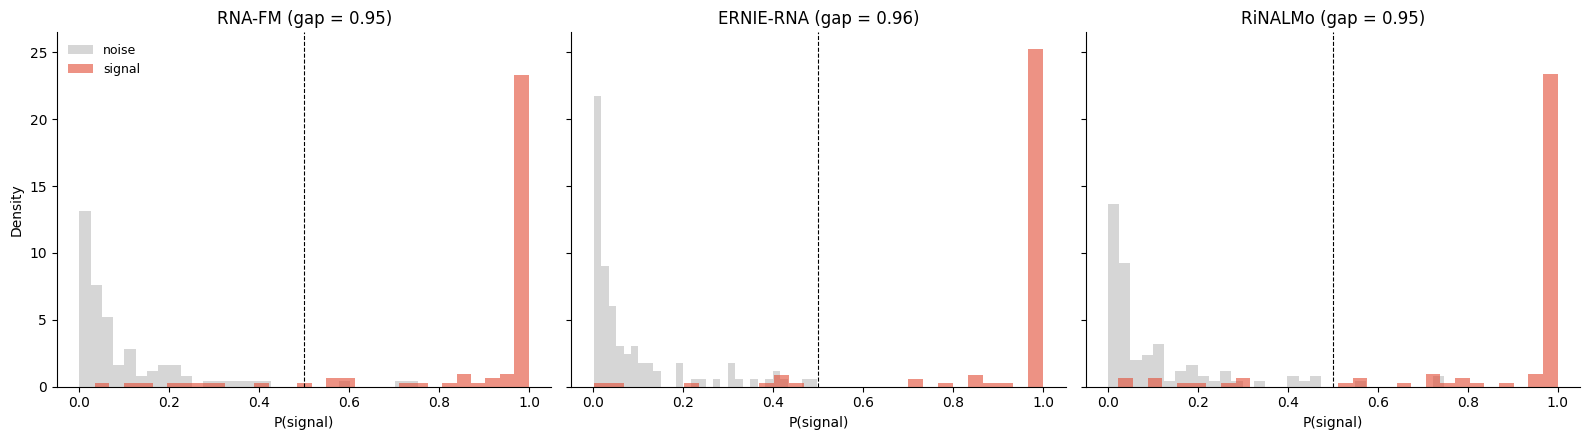

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for idx, mname in enumerate(MODELS):
    ax = axes[idx]
    probs = results[mname]["y_prob"][test_idx]
    labels = y[test_idx]

    ax.hist(probs[labels == 0], bins=30, alpha=0.6, color="#bbb", label="noise", density=True)
    ax.hist(probs[labels == 1], bins=30, alpha=0.6, color="#e24a33", label="signal", density=True)
    ax.axvline(0.5, color="black", ls="--", lw=0.8)

    # Compute probability gap: median(signal) - median(noise)
    gap = np.median(probs[labels == 1]) - np.median(probs[labels == 0])
    ax.set_title(f"{mname} (gap = {gap:.2f})")
    ax.set_xlabel("P(signal)")
    if idx == 0:
        ax.set_ylabel("Density")
        ax.legend(fontsize=9, frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Summary

In [14]:
rows = []
for mname in MODELS:
    r = results[mname]
    probs = r["y_prob"][test_idx]
    labels = y[test_idx]
    gap = np.median(probs[labels == 1]) - np.median(probs[labels == 0])
    rows.append({
        "Model": mname,
        "Emb dim": MODELS[mname]["dim"],
        "Var@k=16": f"{r['var_explained']:.1%}",
        "Train AUC": f"{r['train_auc']:.4f}",
        "Test AUC": f"{r['auc']:.4f}",
        "Prob gap": f"{gap:.3f}",
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

    Model  Emb dim Var@k=16 Train AUC Test AUC Prob gap
   RNA-FM      640    84.9%    0.9847   0.9837    0.949
ERNIE-RNA      768    79.6%    0.9870   0.9828    0.965
  RiNALMo     1280    84.5%    0.9725   0.9733    0.952
